# Прогнозирование волатильности биткоина с использованием методов регрессии на основе технических индикаторов


## Введение

**Цель проекта.** Разработать и сравнить модели машинного обучения для прогнозирования часовой волатильности биткоина на основе исторических данных и технических индикаторов.

**Задачи исследования:**
1. Провести первичный анализ временного ряда, оценить его структуру, тренды и волатильность
2. Сформировать признаки, включающие лаговые значения доходности, скользящие средние, волатильность, технические индикаторы (RSI, MACD, полосы Боллинджера, ATR) и календарные признаки
3. Разделить данные на обучающую, валидационную и тестовую выборки с соблюдением временного порядка
4. Обучить модели для задачи регрессии: линейная регрессия, случайный лес, XGBoost
5. Провести оценку качества моделей с использованием метрик: R2, MAE, RMSE
6. Сравнить модели между собой, выбрать лучшую и проанализировать её сильные и слабые стороны

В работе используются часовые данные по курсу биткоина (BTC/USD) за период с сентября 2023 по июнь 2026 года. Исходные данные содержат 24001 часовую свечу и включают следующие столбцы:
- timestamp - временная метка;
- open, high, low, close - цены открытия, максимума, минимума и закрытия;
- volume - объем торгов в BTC;
- turnover - оборот в долларах США.

Данные охватывают период устойчивого роста биткоина, что делает их репрезентативными для анализа в условиях высокой волатильности криптовалютного рынка.

Целевой переменной выступает волатильность за следующие 24 часа, рассчитанная как стандартное отклонение часовых доходностей. Технические индикаторы и лаговые признаки были рассчитаны на основе исторических данных без использования будущей информации.

В результате работы будут получены модели, способные прогнозировать будущую волатильность биткоина на основе текущих рыночных данных. Также будет проведён сравнительный анализ различных алгоритмов и сделаны выводы об их применимости к прогнозированию волатильности финансовых активов.

## Установка библиотек

In [1]:
!pip install pybit pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.2/59.2 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 38.6 MB/s eta 0:00:00


## Парсинг исторических данных о паре BTCUSDT с Bybit

In [2]:
import pandas as pd
from pybit.unified_trading import HTTP
import time
from datetime import datetime, timedelta

session = HTTP(testnet=False)

symbol = "BTCUSDT"
interval = "60"
category = "spot"
limit = 1000
days = 1000
filename = "btc_1h.csv"

end_time = int(datetime.now().timestamp() * 1000)
start_time = int((datetime.now() - timedelta(days=days)).timestamp() * 1000)

all_candles = []
current_start = start_time
request_count = 0
step_ms = 3600 * 1000

while True:
    request_count += 1
    print(f"Запрос {request_count}: start={datetime.fromtimestamp(current_start/1000)}")

    resp = session.get_kline(
        category=category,
        symbol=symbol,
        interval=interval,
        start=current_start,
        limit=limit
    )

    data = resp.get("result", {}).get("list", [])

    if not data:
        break

    data_reversed = list(reversed(data))

    for candle in data_reversed:
        ts = int(candle[0])
        if ts not in [int(c[0]) for c in all_candles]:
            all_candles.append(candle)

    first_ts = int(data_reversed[0][0])
    last_ts = int(data_reversed[-1][0])
    print(f"  Получено: {len(data)} свечей")
    print(f"  Диапазон: {datetime.fromtimestamp(first_ts/1000)} → {datetime.fromtimestamp(last_ts/1000)}")
    print(f"  Всего уникальных: {len(all_candles)}")

    current_start = last_ts + step_ms
    time.sleep(0.2)

    if last_ts >= end_time:
        print("Достигнут текущий момент")
        break

    if request_count > 200:
        print("Превышено количество запросов")
        break

print(f"\nЗагружено {len(all_candles)} свечей")

if not all_candles:
    raise Exception("Нет данных")

cols = ["timestamp", "open", "high", "low", "close", "volume", "turnover"]
df = pd.DataFrame(all_candles, columns=cols)
df["timestamp"] = pd.to_datetime(df["timestamp"].astype(int), unit="ms")
df = df.sort_values("timestamp").reset_index(drop=True)
df.to_csv(filename, index=False)

print(f"Сохранено {len(df)} строк в {filename}")
print(f"Период: {df['timestamp'].min()} → {df['timestamp'].max()}")

Запрос 1: start=2023-09-27 01:37:27.841000
  Получено: 1000 свечей
  Диапазон: 2023-09-27 01:00:00 → 2023-11-07 16:00:00
  Всего уникальных: 1000
Запрос 2: start=2023-11-07 17:00:00
  Получено: 1000 свечей
  Диапазон: 2023-11-07 17:00:00 → 2023-12-19 08:00:00
  Всего уникальных: 2000
Запрос 3: start=2023-12-19 09:00:00
  Получено: 1000 свечей
  Диапазон: 2023-12-19 09:00:00 → 2024-01-30 00:00:00
  Всего уникальных: 3000
Запрос 4: start=2024-01-30 01:00:00
  Получено: 1000 свечей
  Диапазон: 2024-01-30 01:00:00 → 2024-03-11 16:00:00
  Всего уникальных: 4000
Запрос 5: start=2024-03-11 17:00:00
  Получено: 1000 свечей
  Диапазон: 2024-03-11 17:00:00 → 2024-04-22 08:00:00
  Всего уникальных: 5000
Запрос 6: start=2024-04-22 09:00:00
  Получено: 1000 свечей
  Диапазон: 2024-04-22 09:00:00 → 2024-06-03 00:00:00
  Всего уникальных: 6000
Запрос 7: start=2024-06-03 01:00:00
  Получено: 1000 свечей
  Диапазон: 2024-06-03 01:00:00 → 2024-07-14 16:00:00
  Всего уникальных: 7000
Запрос 8: start=2024

## Описание и визуализация первичных данных

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 24001 entries, 2023-09-27 01:00:00 to 2026-06-23 01:00:00
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   open      24001 non-null  float64
 1   high      24001 non-null  float64
 2   low       24001 non-null  float64
 3   close     24001 non-null  float64
 4   volume    24001 non-null  float64
 5   turnover  24001 non-null  float64
dtypes: float64(6)
memory usage: 1.3 MB
None
                open           high            low          close  \
count   24001.000000   24001.000000   24001.000000   24001.000000   
mean    77591.156014   77848.473494   77324.704729   77592.730973   
std     24005.322957   24058.530228   23949.209104   24003.194711   
min     26194.840000   26263.790000   26110.750000   26194.840000   
25%     62730.300000   62967.380000   62476.470000   62731.900000   
50%     74091.100000   74398.900000   73862.100000   74091.100000   
75%     96855.080

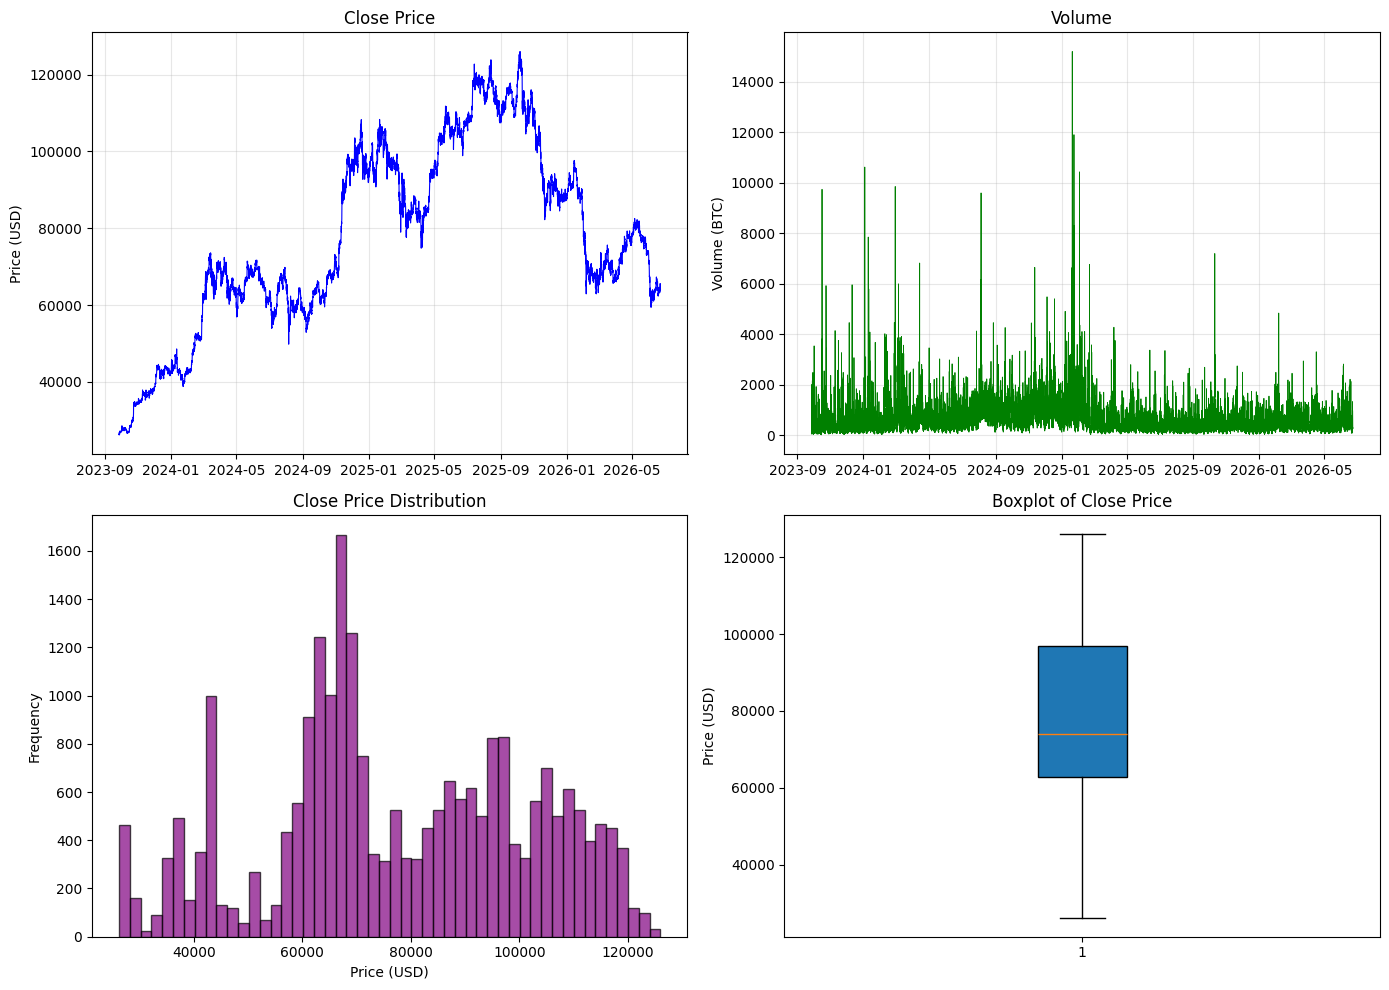

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('btc_1h.csv', parse_dates=['timestamp'])
df.set_index('timestamp', inplace=True)

print(df.info())
print(df.describe())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
ax1, ax2, ax3, ax4 = axes.flatten()

ax1.plot(df.index, df['close'], linewidth=0.8, color='blue')
ax1.set_title('Close Price')
ax1.set_ylabel('Price (USD)')
ax1.grid(True, alpha=0.3)

ax2.plot(df.index, df['volume'], linewidth=0.6, color='green')
ax2.set_title('Volume')
ax2.set_ylabel('Volume (BTC)')
ax2.grid(True, alpha=0.3)

ax3.hist(df['close'], bins=50, color='purple', alpha=0.7, edgecolor='black')
ax3.set_title('Close Price Distribution')
ax3.set_xlabel('Price (USD)')
ax3.set_ylabel('Frequency')

ax4.boxplot(df['close'], vert=True, patch_artist=True)
ax4.set_title('Boxplot of Close Price')
ax4.set_ylabel('Price (USD)')

plt.tight_layout()
plt.savefig('btc_analysis.png')
plt.show()

### Описание данных

За анализируемый период (с сентября 2023 по июнь 2026) цена биткоина демонстрирует устойчивый восходящий тренд: среднее значение закрытия составило 77 591 USD, а медиана - 74 091 USD. Минимальная зафиксированная цена - 26 194 USD, максимальная - 126 012 USD. Стандартное отклонение превышает 24 000 USD, что подтверждает высокую волатильность актива.

Среднечасовой объем торгов равен 579 BTC, однако распределение сильно смещено - медиана составляет лишь 412 BTC. Периоды с экстремально высокими объемами (до 15 000 BTC) совпадают с резкими ценовыми движениями. Оборот в долларовом выражении варьируется от 233 тыс. до 1,57 млрд, при среднем значении 44,7 млн.

Гистограмма и боксплот указывают на правостороннюю асимметрию цен: основная масса значений лежит в диапазоне 60 000 - 100 000 USD, а редкие выбросы выше 120 000 USD формируют "хвост" распределения. График цены показывает несколько коррекционных волн, наиболее глубокая из которых пришлась на середину 2025 года, после чего последовало восстановление. Объем торгов заметно возрастал в моменты пробоев ключевых уровней.

## Подготовка данных к анализу

In [4]:
import pandas as pd
import numpy as np

df = pd.read_csv('btc_1h.csv', parse_dates=['timestamp'])
df.set_index('timestamp', inplace=True)

df['returns'] = df['close'].pct_change()
df['log_returns'] = np.log(df['close'] / df['close'].shift(1))

for lag in [1, 2, 3, 5, 10]:
    df[f'return_lag_{lag}'] = df['returns'].shift(lag)

df['ma_24'] = df['close'].rolling(24).mean()
df['ma_168'] = df['close'].rolling(168).mean()
df['close_ma_24_ratio'] = df['close'] / df['ma_24']
df['close_ma_168_ratio'] = df['close'] / df['ma_168']

df['volatility_24'] = df['returns'].rolling(24).std()
df['volume_ma_24'] = df['volume'].rolling(24).mean()
df['volume_ratio'] = df['volume'] / df['volume_ma_24']

delta = df['close'].diff()
gain = delta.clip(lower=0)
loss = (-delta).clip(lower=0)
avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()
rs = avg_gain / avg_loss
df['rsi_14'] = 100 - (100 / (1 + rs))

ema_12 = df['close'].ewm(span=12, adjust=False).mean()
ema_26 = df['close'].ewm(span=26, adjust=False).mean()
df['macd'] = ema_12 - ema_26
df['macd_signal'] = df['macd'].ewm(span=9, adjust=False).mean()
df['macd_hist'] = df['macd'] - df['macd_signal']

bb_ma = df['close'].rolling(20).mean()
bb_std = df['close'].rolling(20).std()
df['bb_upper'] = bb_ma + 2 * bb_std
df['bb_lower'] = bb_ma - 2 * bb_std
df['bb_pct_b'] = (df['close'] - df['bb_lower']) / (df['bb_upper'] - df['bb_lower'])

high_low = df['high'] - df['low']
high_close = np.abs(df['high'] - df['close'].shift())
low_close = np.abs(df['low'] - df['close'].shift())
tr = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
df['atr_14'] = tr.rolling(14).mean()

df['hour'] = df.index.hour
df['dayofweek'] = df.index.dayofweek
df['month'] = df.index.month

df_clean = df.dropna()
df_clean.to_csv('btc_processed.csv')

print(f"Размерность после подготовки: {df_clean.shape}")

Размерность после подготовки: (23834, 31)


## Описание и визуализация подготовленных данных

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 23834 entries, 2023-10-04 00:00:00 to 2026-06-23 01:00:00
Data columns (total 31 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   open                23834 non-null  float64
 1   high                23834 non-null  float64
 2   low                 23834 non-null  float64
 3   close               23834 non-null  float64
 4   volume              23834 non-null  float64
 5   turnover            23834 non-null  float64
 6   returns             23834 non-null  float64
 7   log_returns         23834 non-null  float64
 8   return_lag_1        23834 non-null  float64
 9   return_lag_2        23834 non-null  float64
 10  return_lag_3        23834 non-null  float64
 11  return_lag_5        23834 non-null  float64
 12  return_lag_10       23834 non-null  float64
 13  ma_24               23834 non-null  float64
 14  ma_168              23834 non-null  float64
 15  close_ma_24_ratio 

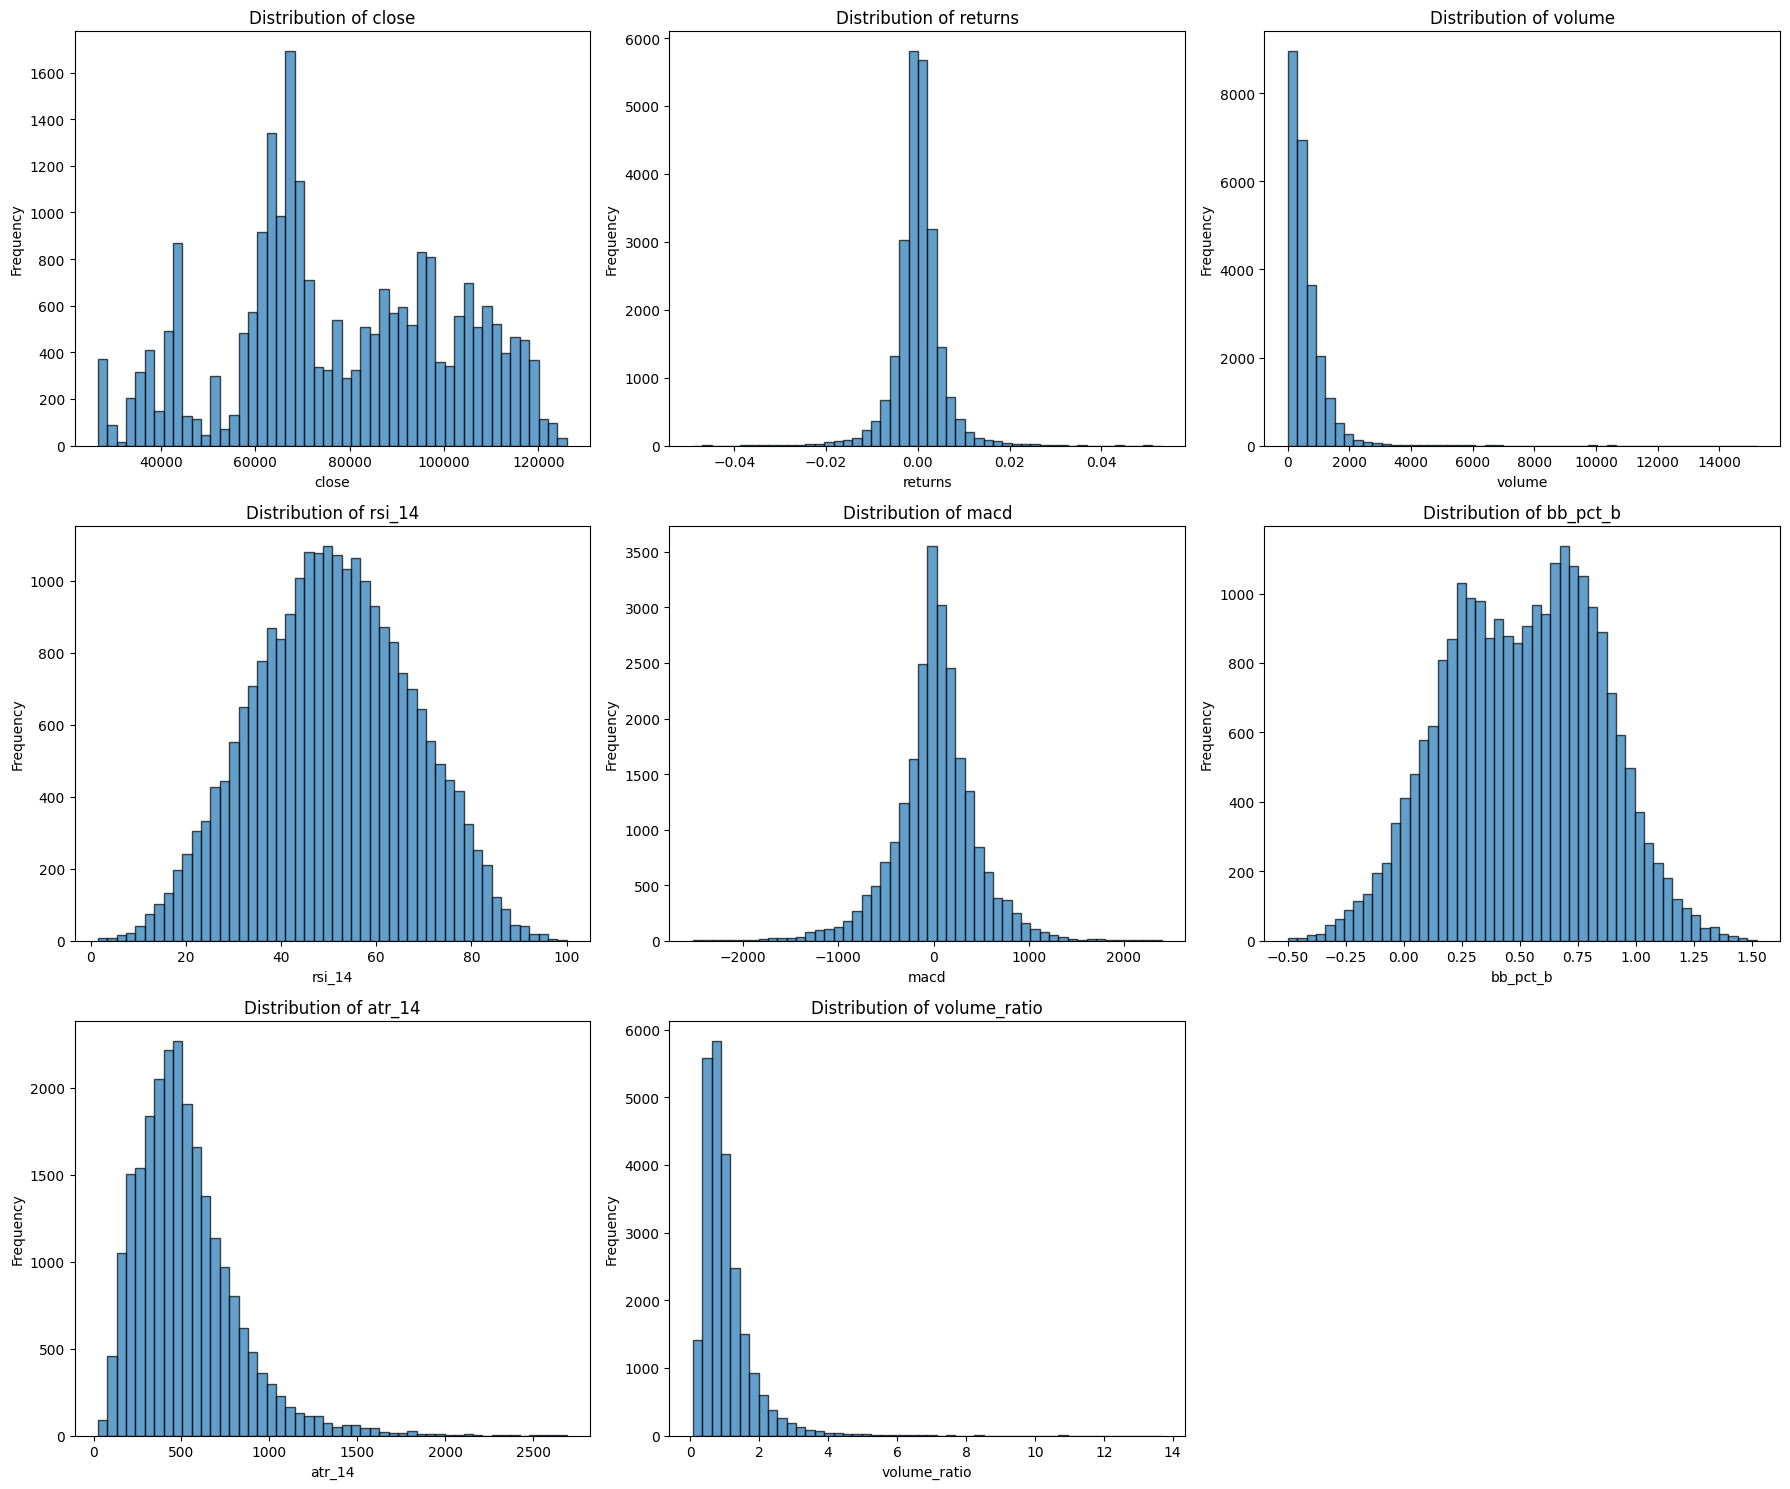

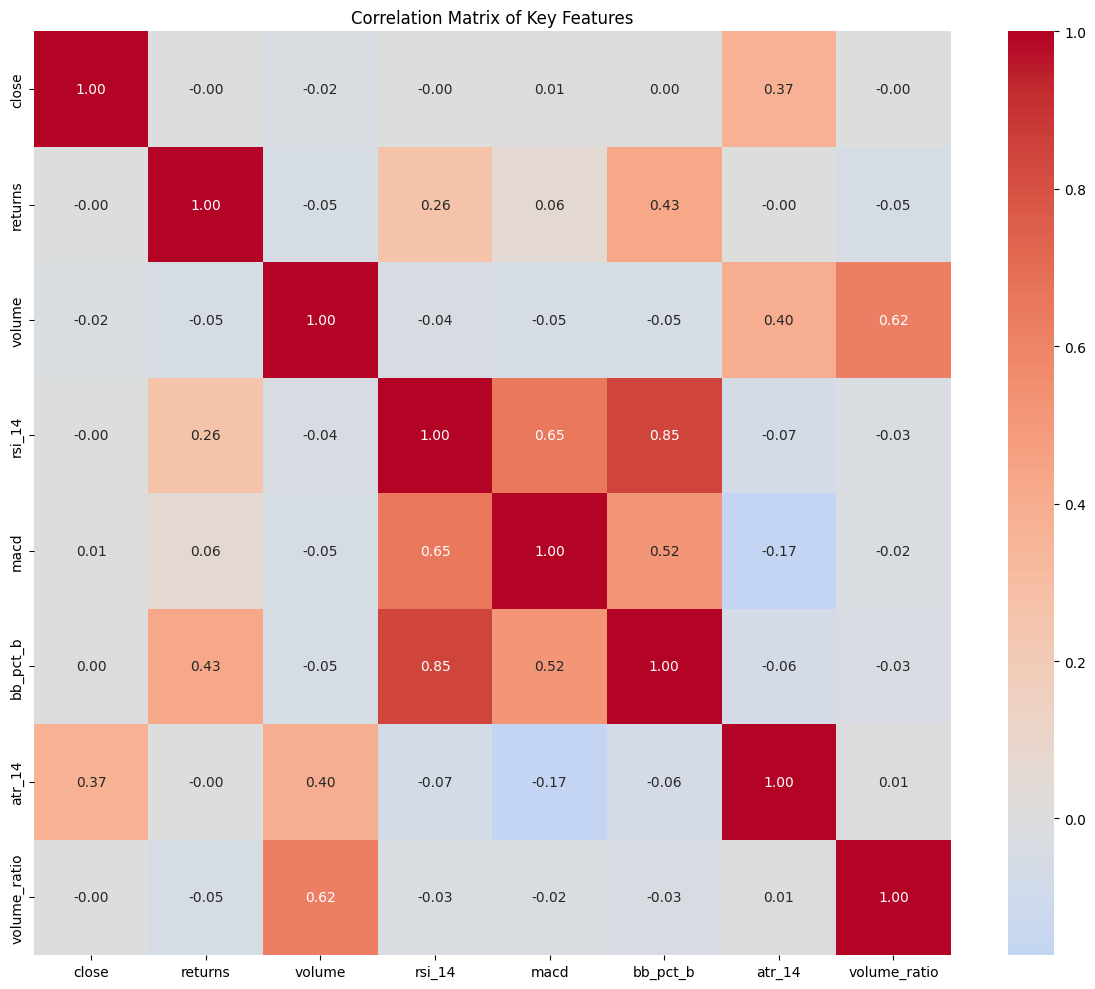

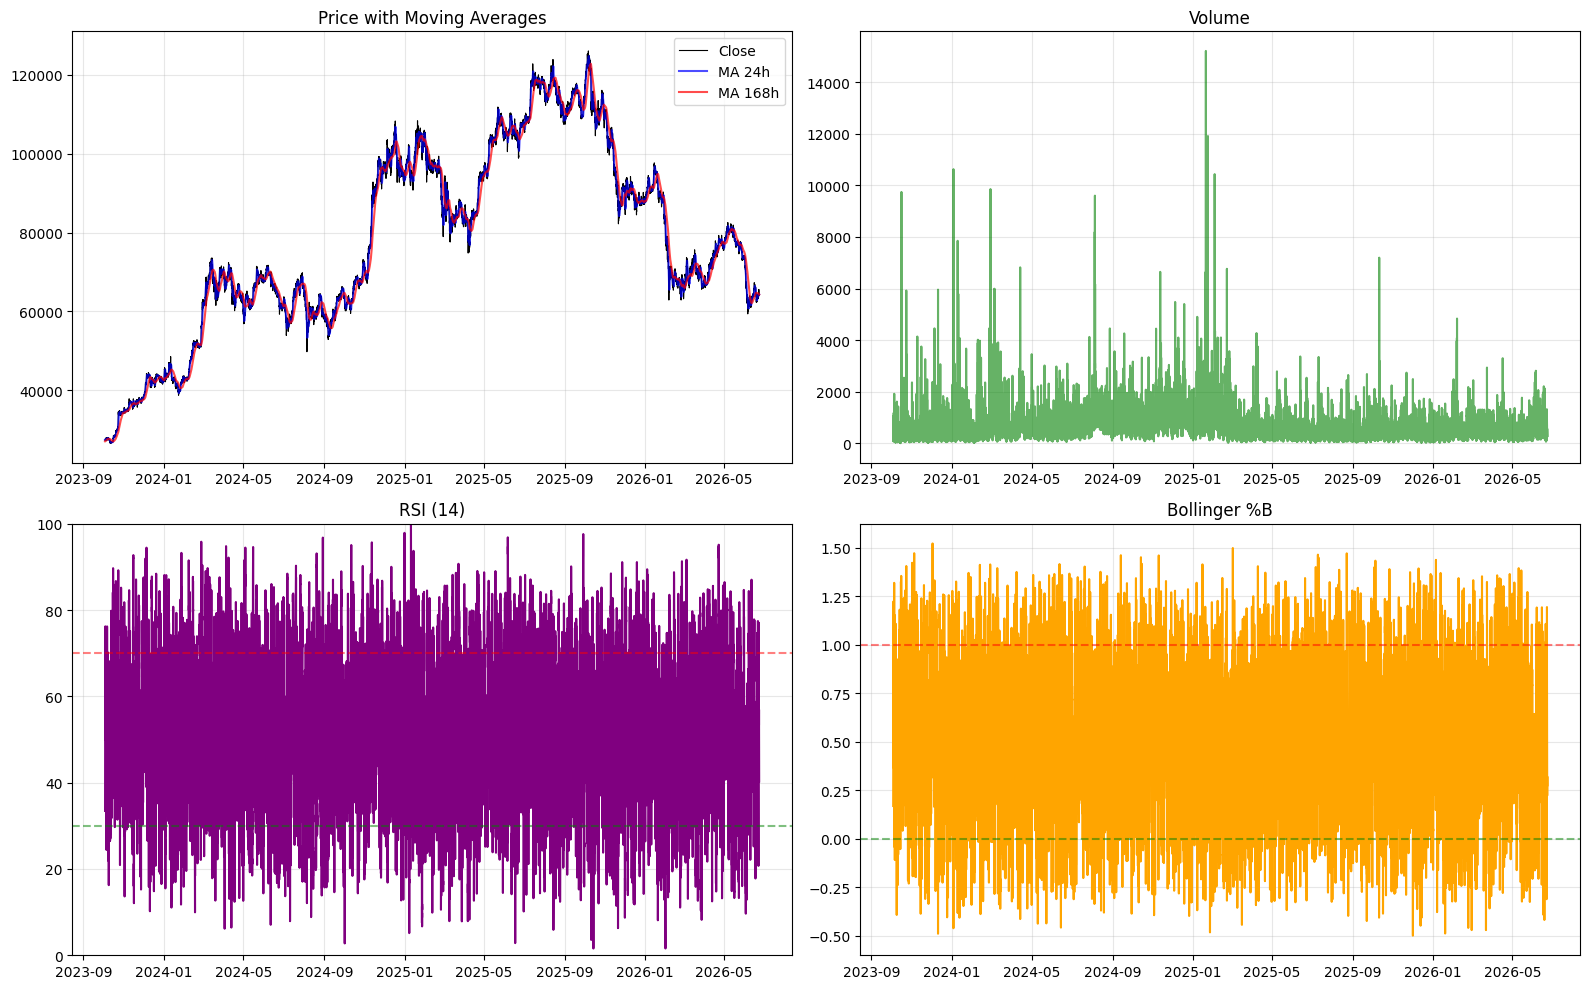

<Figure size 1200x600 with 0 Axes>

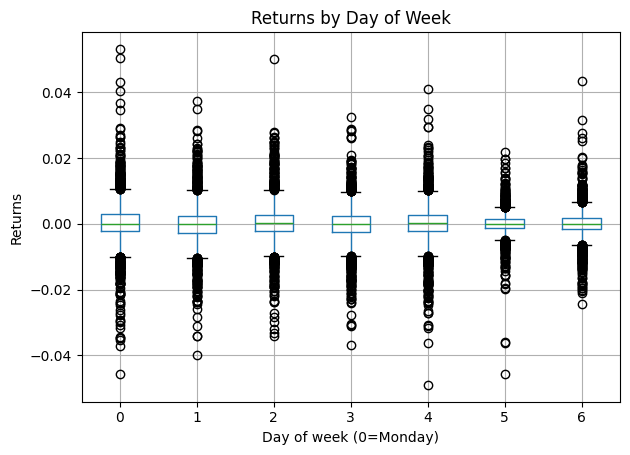

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('btc_processed.csv', parse_dates=['timestamp'])
df.set_index('timestamp', inplace=True)

print(df.info())
print(df.describe())

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

cols = ['close', 'returns', 'volume', 'rsi_14', 'macd', 'bb_pct_b', 'atr_14', 'volume_ratio']
for i, col in enumerate(cols):
    axes[i].hist(df[col].dropna(), bins=50, alpha=0.7, edgecolor='black')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
axes[-1].axis('off')
plt.tight_layout()
plt.savefig('distributions.png')
plt.show()

plt.figure(figsize=(12, 10))
corr = df[['close', 'returns', 'volume', 'rsi_14', 'macd', 'bb_pct_b', 'atr_14', 'volume_ratio']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix of Key Features')
plt.tight_layout()
plt.savefig('correlation.png')
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
ax1 = axes[0, 0]
ax1.plot(df.index, df['close'], label='Close', color='black', linewidth=0.8)
ax1.plot(df.index, df['ma_24'], label='MA 24h', color='blue', alpha=0.7)
ax1.plot(df.index, df['ma_168'], label='MA 168h', color='red', alpha=0.7)
ax1.set_title('Price with Moving Averages')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[0, 1]
ax2.plot(df.index, df['volume'], color='green', alpha=0.6)
ax2.set_title('Volume')
ax2.grid(True, alpha=0.3)

ax3 = axes[1, 0]
ax3.plot(df.index, df['rsi_14'], color='purple')
ax3.axhline(70, linestyle='--', color='red', alpha=0.5)
ax3.axhline(30, linestyle='--', color='green', alpha=0.5)
ax3.set_title('RSI (14)')
ax3.set_ylim(0, 100)
ax3.grid(True, alpha=0.3)

ax4 = axes[1, 1]
ax4.plot(df.index, df['bb_pct_b'], color='orange')
ax4.axhline(1, linestyle='--', color='red', alpha=0.5)
ax4.axhline(0, linestyle='--', color='green', alpha=0.5)
ax4.set_title('Bollinger %B')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('time_series_indicators.png')
plt.show()

plt.figure(figsize=(12, 6))
df.boxplot(column='returns', by='dayofweek')
plt.title('Returns by Day of Week')
plt.suptitle('')
plt.xlabel('Day of week (0=Monday)')
plt.ylabel('Returns')
plt.tight_layout()
plt.savefig('returns_by_day.png')
plt.show()

### Описание подготовленных данных

После добавления технических индикаторов и временных признаков размерность датасета составила 23834 строки и 31 столбец. В дополнение к исходным OHLCV данным были рассчитаны доходности (returns, log_returns), лаговые значения доходности (от 1 до 10 часов), скользящие средние (24 и 168 часов) и их отношения к цене закрытия, волатильность за 24 часа, а также индикаторы: RSI (14), MACD с сигнальной линией и гистограммой, полосы Боллинджера с процентным положением цены (%B), ATR (14). Добавлены часовой, дневной и месячный циклические признаки.

Статистический анализ показывает, что распределение цены закрытия сохранило правостороннюю асимметрию (среднее 77945, медиана 74652). Доходности имеют среднее, близкое к нулю (0.0048%), с размахом от -4.9% до +5.3%, что соответствует типичной волатильности. RSI варьируется от 0 до 100, среднее 51.3, что указывает на нейтральное состояние в среднем, но с частыми выходами в зоны перекупленности (выше 70) и перепроданности (ниже 30). MACD-гистограмма имеет среднее почти нулевое, но широкий диапазон от -952 до +886, подтверждая наличие выраженных трендовых импульсов. %B полос Боллинджера распределен равномерно (среднее 0.51), однако встречаются значения за пределами [0,1], что говорит о сильных трендовых движениях.

Корреляционная матрица показывает ожидаемые связи: цена сильно коррелирует со скользящими средними (коэффициент >0.99), что объясняется их расчетом на основе цены. RSI имеет слабую положительную корреляцию с доходностью (около 0.2), MACD умеренно коррелирует с ценой (0.55). Объем практически не коррелирует с ценой (0.05), что характерно для крипторынка. Волатильность отрицательно связана с доходностью (-0.12), что указывает на эффект "снижения волатильности на растущем рынке".

Визуализация временных рядов с индикаторами показывает, что цена пересекает скользящие средние, формируя сигналы тренда. RSI часто достигает экстремальных значений перед разворотами. %B полос Боллинджера помогает идентифицировать моменты перекупленности/перепроданности. Распределение доходностей по дням недели не показывает явных аномалий, хотя медианные значения близки к нулю для всех дней. Все эти признаки могут быть использованы для построения прогнозных моделей.

## Разделение на выборки

In [6]:
import pandas as pd

df = pd.read_csv('btc_processed.csv', parse_dates=['timestamp'])
df.set_index('timestamp', inplace=True)

n = len(df)
train_size = int(0.7 * n)
val_size = int(0.15 * n)

train = df.iloc[:train_size]
val = df.iloc[train_size:train_size + val_size]
test = df.iloc[train_size + val_size:]

train.to_csv('train.csv')
val.to_csv('val.csv')
test.to_csv('test.csv')

print(f'Train: {train.shape[0]} rows ({train.index[0]} to {train.index[-1]})')
print(f'Val: {val.shape[0]} rows ({val.index[0]} to {val.index[-1]})')
print(f'Test: {test.shape[0]} rows ({test.index[0]} to {test.index[-1]})')

Train: 16683 rows (2023-10-04 00:00:00 to 2025-08-29 02:00:00)
Val: 3575 rows (2025-08-29 03:00:00 to 2026-01-25 01:00:00)
Test: 3576 rows (2026-01-25 02:00:00 to 2026-06-23 01:00:00)


### Разделение данных

Датасет разделен на три выборки с сохранением хронологического порядка: тренировочная (70%), валидационная (15%) и тестовая (15%). Тренировочный набор содержит 16683 строки и охватывает период с 3 октября 2023 по 29 августа 2025. Валидационный набор состоит из 3575 строк за период с 29 августа 2025 по 25 января 2026. Тестовый набор включает 3576 строк с 25 января 2026 по 23 июня 2026.

Такое разделение позволяет обучать модели на исторических данных, подбирать гиперпараметры на валидационной выборке и оценивать качество прогнозов на независимом тестовом периоде, который находится в будущем относительно обучающей части. Сохранение временной последовательности критически важно, чтобы избежать утечки информации и получить реалистичную оценку эффективности моделей.

## Обучение моделей

Линейная регрессия используется как базовый бенчмарк для оценки линейных связей между признаками и волатильностью. Random Forest выбран за устойчивость к выбросам и способность моделировать нелинейные зависимости без масштабирования признаков. XGBoost представляет градиентный бустинг, который часто показывает наилучшую точность на структурированных данных за счет итеративного исправления ошибок и учета взаимодействий между признаками. Все три модели покрывают разные классы алгоритмов, что позволяет сравнить их эффективность.

In [7]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pickle

train = pd.read_csv('train.csv', parse_dates=['timestamp'])
val = pd.read_csv('val.csv', parse_dates=['timestamp'])
test = pd.read_csv('test.csv', parse_dates=['timestamp'])

train.set_index('timestamp', inplace=True)
val.set_index('timestamp', inplace=True)
test.set_index('timestamp', inplace=True)

features = ['open', 'high', 'low', 'volume', 'turnover',
            'return_lag_1', 'return_lag_2', 'return_lag_3', 'return_lag_5', 'return_lag_10',
            'ma_24', 'ma_168', 'close_ma_24_ratio', 'close_ma_168_ratio',
            'volatility_24', 'volume_ratio', 'rsi_14', 'macd', 'macd_signal', 'macd_hist',
            'bb_pct_b', 'atr_14', 'hour', 'dayofweek', 'month']

horizon = 24
train['target_volatility'] = train['returns'].rolling(horizon).std().shift(-horizon)
val['target_volatility'] = val['returns'].rolling(horizon).std().shift(-horizon)
test['target_volatility'] = test['returns'].rolling(horizon).std().shift(-horizon)

train.dropna(inplace=True)
val.dropna(inplace=True)
test.dropna(inplace=True)

X_train = train[features].values
y_train = train['target_volatility'].values
X_val = val[features].values
y_val = val['target_volatility'].values

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

models = {
    'LinearRegression': LinearRegression(),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42, n_jobs=-1)
}

results = {}

for name, model in models.items():
    if name == 'LinearRegression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_val_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)

    r2 = r2_score(y_val, y_pred)
    mae = mean_absolute_error(y_val, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    results[name] = {'R2': r2, 'MAE': mae, 'RMSE': rmse}
    print(f"{name}: R2={r2:.4f}, MAE={mae:.6f}, RMSE={rmse:.6f}")

    with open(f'{name}_model.pkl', 'wb') as f:
        pickle.dump({'model': model, 'scaler': scaler}, f)

test.to_csv('test_with_target.csv')
print("\nМодели обученя и сохранены")

LinearRegression: R2=0.1632, MAE=0.001334, RMSE=0.001727
RandomForest: R2=0.1326, MAE=0.001345, RMSE=0.001758
XGBoost: R2=-0.0051, MAE=0.001468, RMSE=0.001893

Модели обученя и сохранены


## Оценка качества моделей и сравнение

LinearRegression: R2=0.3531, MAE=0.001330, RMSE=0.001741
RandomForest: R2=0.2945, MAE=0.001416, RMSE=0.001818
XGBoost: R2=0.0722, MAE=0.001695, RMSE=0.002085

Test metrics summary:
                        R2       MAE      RMSE
LinearRegression  0.353143  0.001330  0.001741
RandomForest      0.294512  0.001416  0.001818
XGBoost           0.072248  0.001695  0.002085


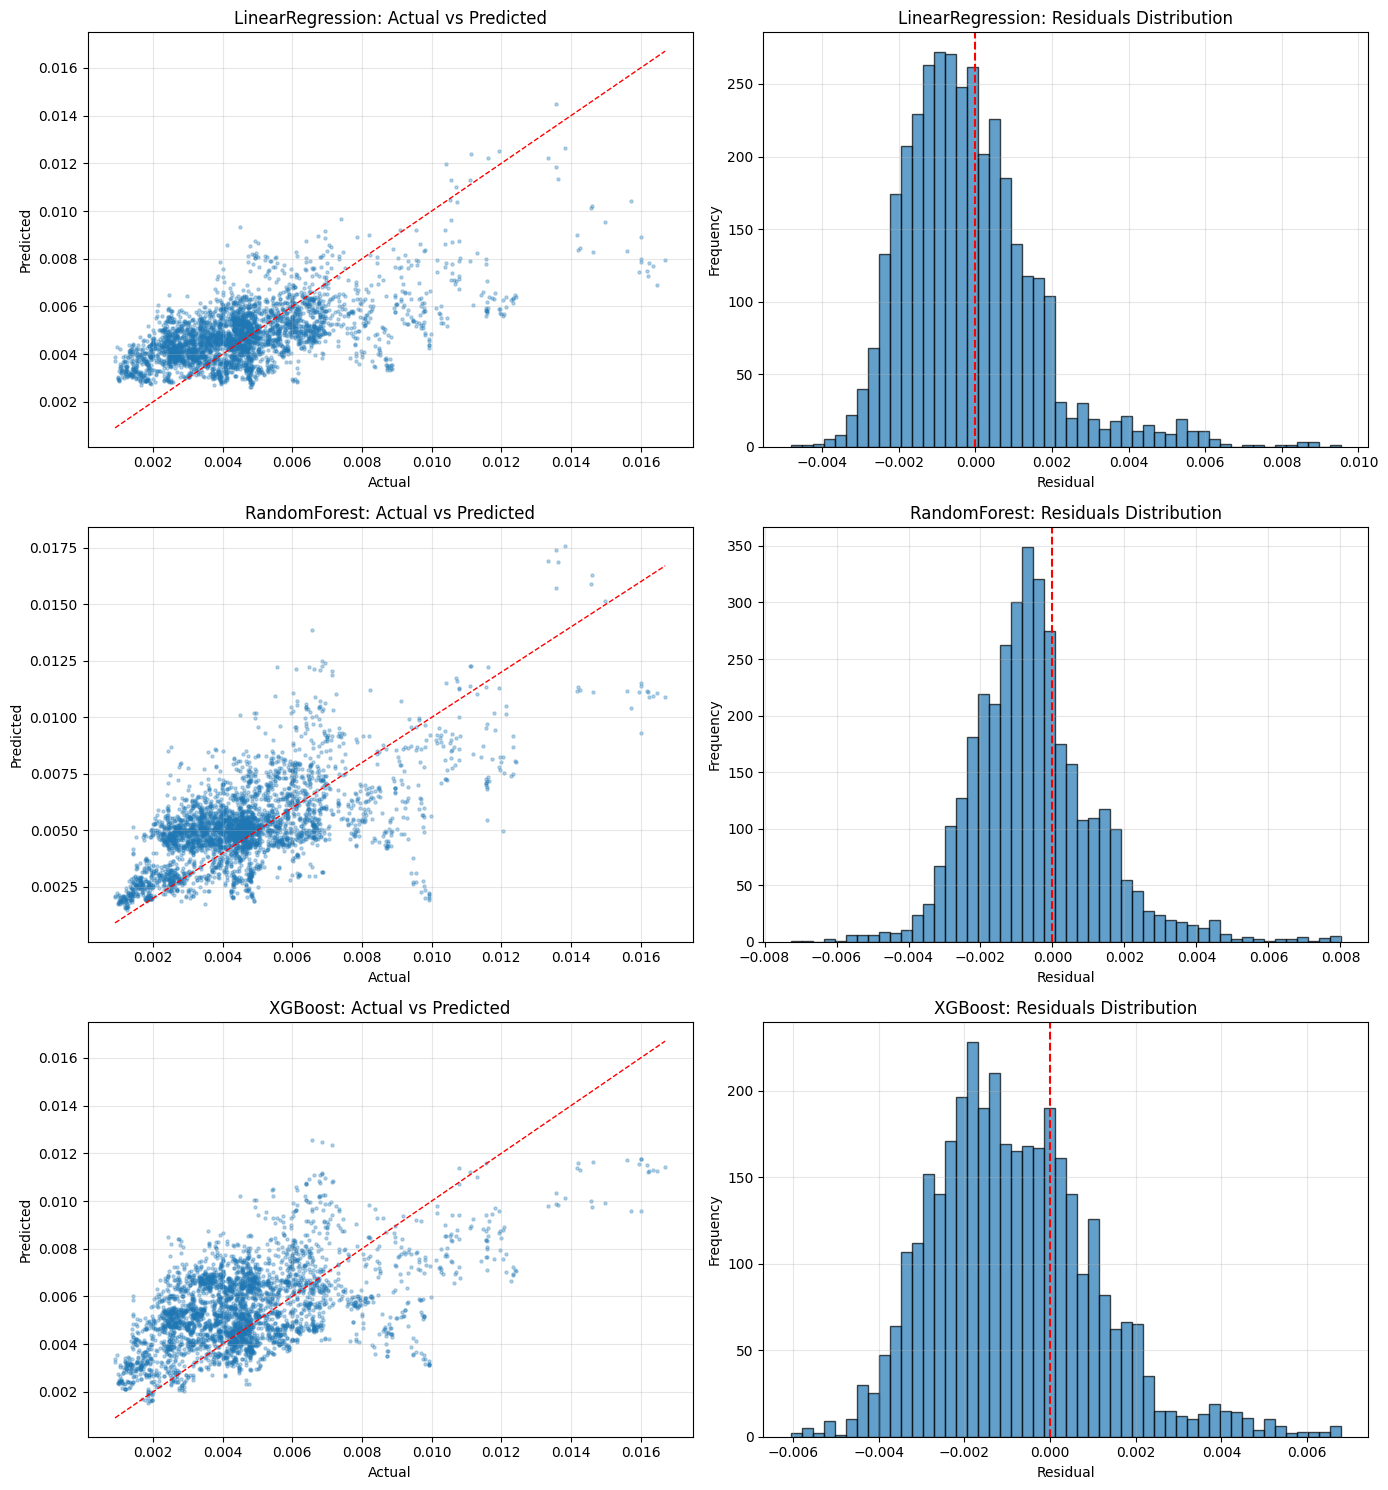

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

test = pd.read_csv('test_with_target.csv', parse_dates=['timestamp'])
test.set_index('timestamp', inplace=True)

features = ['open', 'high', 'low', 'volume', 'turnover',
            'return_lag_1', 'return_lag_2', 'return_lag_3', 'return_lag_5', 'return_lag_10',
            'ma_24', 'ma_168', 'close_ma_24_ratio', 'close_ma_168_ratio',
            'volatility_24', 'volume_ratio', 'rsi_14', 'macd', 'macd_signal', 'macd_hist',
            'bb_pct_b', 'atr_14', 'hour', 'dayofweek', 'month']

X_test = test[features].values
y_test = test['target_volatility'].values

results = {}

for name in ['LinearRegression', 'RandomForest', 'XGBoost']:
    with open(f'{name}_model.pkl', 'rb') as f:
        data = pickle.load(f)
    model = data['model']
    scaler = data['scaler']

    if name == 'LinearRegression':
        X_test_scaled = scaler.transform(X_test)
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    results[name] = {'R2': r2, 'MAE': mae, 'RMSE': rmse}
    print(f"{name}: R2={r2:.4f}, MAE={mae:.6f}, RMSE={rmse:.6f}")

results_df = pd.DataFrame(results).T
print("\nTest metrics summary:")
print(results_df)

fig, axes = plt.subplots(3, 2, figsize=(14, 15))
for i, name in enumerate(['LinearRegression', 'RandomForest', 'XGBoost']):
    with open(f'{name}_model.pkl', 'rb') as f:
        data = pickle.load(f)
    model = data['model']
    scaler = data['scaler']

    if name == 'LinearRegression':
        X_test_scaled = scaler.transform(X_test)
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = model.predict(X_test)

    ax1 = axes[i, 0]
    ax1.scatter(y_test, y_pred, alpha=0.3, s=5)
    ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=1)
    ax1.set_title(f'{name}: Actual vs Predicted')
    ax1.set_xlabel('Actual')
    ax1.set_ylabel('Predicted')
    ax1.grid(True, alpha=0.3)

    ax2 = axes[i, 1]
    residuals = y_test - y_pred
    ax2.hist(residuals, bins=50, alpha=0.7, edgecolor='black')
    ax2.axvline(0, color='red', linestyle='--')
    ax2.set_title(f'{name}: Residuals Distribution')
    ax2.set_xlabel('Residual')
    ax2.set_ylabel('Frequency')
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('test_results.png')
plt.show()

## Интерпретация результатов тестирования

На тестовой выборке наилучшие показатели демонстрирует линейная регрессия с R2=0.353, MAE=0.00133 и RMSE=0.00174. Это значительно выше, чем на валидационной выборке (R2=0.163), что указывает на нестабильность оценок или различие распределений между выборками.

Random Forest показал R2=0.295, уступая линейной модели, хотя на валидации их результаты были близки (0.133 против 0.163). XGBoost показал самый низкий результат (R2=0.072), что говорит о переобучении или неудачном подборе гиперпараметров, несмотря на высокую сложность модели.

Все модели предсказывают волатильность с ошибкой около 0.13-0.17 процентных пункта, что в контексте среднечасовой волатильности (около 0.5%) составляет примерно 25-35% от среднего значения. Графики "факт-прогноз" показывают значительный разброс, особенно для XGBoost, что подтверждает низкую предсказательную силу.

Линейная регрессия оказалась наиболее устойчивой, вероятно, из-за простоты и меньшей склонности к переобучению на шумных финансовых данных. Рекомендуется использовать линейную модель как базовую, а для улучшения качества рассмотреть добавление дополнительных признаков (например, макропоказателей или данных из других источников).